# Import & cleaning 

In [72]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv('social media.csv')

df = pd.DataFrame(data)

df.dropna(subset=['gender'] , inplace=True)

# inplace => just edit the existing df dont create new one 

# print(df['occupation'].value_counts())

# print(df['region'].value_counts()) # val counts => if all unique == no outliers  

# print(df['platforms_used_count'].value_counts())

# print(df['daily_screen_hours'].describe())

# print(df['daily_screen_hours'].unique()) # => no outliers

# print(df['minutes_to_first_check_after_waking'].describe())

# df['avg_sleep_hours'] = df['avg_sleep_hours'].fillna(df['avg_sleep_hours'].median(),inplace=True)

# Replace all na values in this col with the median 

# print(df['avg_sleep_hours'].describe())

df['uses_screen_time_limits'] = df['uses_screen_time_limits'].map({
    'Yes' : True,
    'No': False
})

# convert the col from obj / srt to bool 










## Q1 : What is the most used social media platform among users ?

most_used_platform
TikTok    1716
Name: count, dtype: int64


<function matplotlib.pyplot.show(close=None, block=None)>

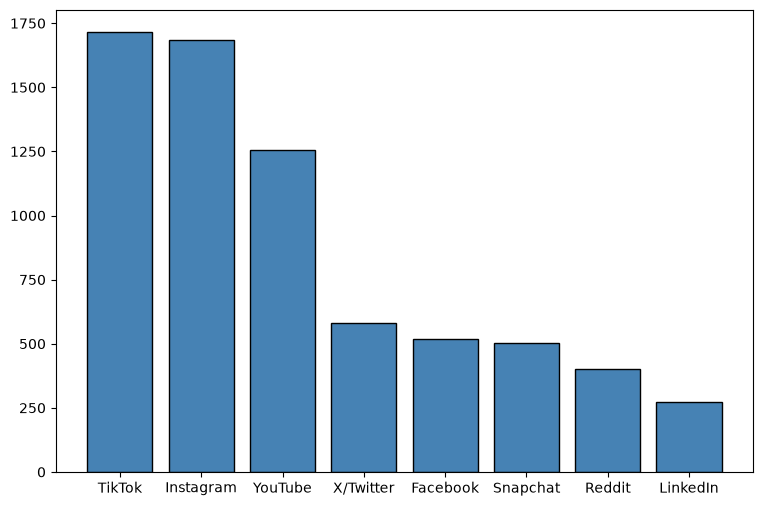

In [ ]:
print(df['most_used_platform'].value_counts().head(1))

chart1 = df['most_used_platform'].value_counts()

plt.figure(figsize=(9,6))

plt.bar(chart1.index,chart1.values,color='steelblue',edgecolor='black')


plt.show



TikTok has the highest user adoption, so it may represent the platform with the strongest engagement among the participants.

# Q2 : What is the average daily screen time among users?

In [48]:
print(df['daily_screen_hours'].mean().round(1)) 

3.3


Users spend an average of 3.3 hours/day on screens indicating a moderate level of digital engagement.

# Q3 : Which social media platform has the highest average daily screen time?

most_used_platform
Facebook    3.43
Name: daily_screen_hours, dtype: float64


<BarContainer object of 8 artists>

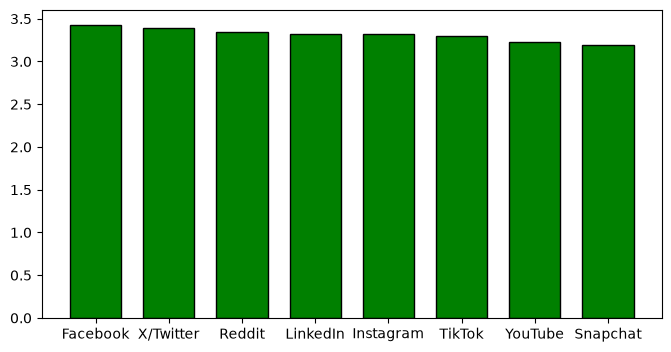

In [99]:
print(df.groupby('most_used_platform')['daily_screen_hours'].mean().round(2).sort_values(ascending=False).head(1))

chart2 = df.groupby('most_used_platform')['daily_screen_hours'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,4))
plt.bar(chart2.index,chart2.values,color='green',edgecolor='black',width=0.7)


Facebook users have the highest average daily screen time, which may indicate higher daily engagement compared with users of other platforms.

# Q4 : Is higher screen time associated with higher anxiety levels?

In [50]:
print(df['daily_screen_hours'].corr(df['anxiety_score_0to27']).round(1)) # 0.5

0.5


This indicates a moderate positive relationship, suggesting that users with higher screen usage tend to have higher anxiety scores.

#

# Q5 : Does night-time screen use affect average sleep hours?

In [51]:
print(df.groupby('night_time_use')['avg_sleep_hours'].mean().round(1).sort_values())



night_time_use
Every night    6.4
Often          6.8
Sometimes      7.2
Never          7.5
Name: avg_sleep_hours, dtype: float64


Users who use social media more frequently at night tend to sleep fewer hours on average. However, the difference is relatively small, with about a 1.1-hour gap between the highest and lowest groups.

# Q6 : Does social comparison affect self-esteem ?

In [52]:
print(df['self_esteem_1to10'].corr(df['social_comparison_1to10']).round(1)) # -0.1

-0.1


There is a very weak negative relationship, indicating that social comparison has little association with self-esteem.

# Q7 : Do users who seek mental health support report lower anxiety levels ?

In [53]:
print(df.groupby('seeks_mental_health_support')['anxiety_score_0to27'].mean().round(1))

# 11.4 for 'Yes'

seeks_mental_health_support
Considering it    11.5
No                11.4
Yes               11.1
Name: anxiety_score_0to27, dtype: float64


Mental health support status showed little association with anxiety levels.

# Q8 :  Which platform has the highest FOMO ?

most_used_platform
Facebook    4.79
Name: fomo_1to10, dtype: float64


<BarContainer object of 8 artists>

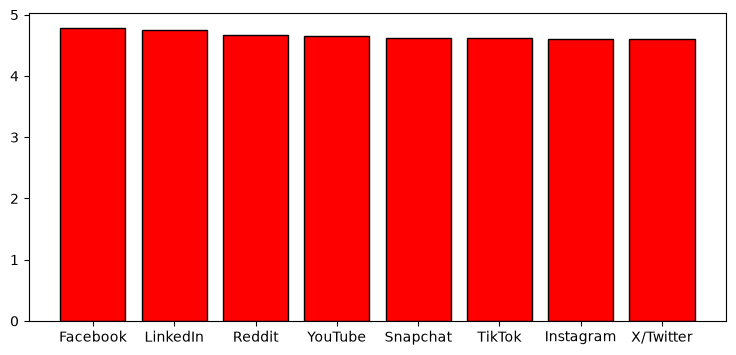

In [104]:
print(df.groupby('most_used_platform')['fomo_1to10'].mean().round(2).sort_values(ascending=False).head(1))

chart3 = df.groupby('most_used_platform')['fomo_1to10'].mean().sort_values(ascending=False)

plt.figure(figsize=(9,4))

plt.bar(chart3.index,chart3.values,edgecolor='black',color='red')

Facebook users reported the highest average FOMO score (4.79) among all social media platforms in the dataset.

In [105]:
df.to_csv('social media analysis.csv' , encoding='utf-8-sig',index=False)